# Stage 10a — Linear Regression

Baseline value model for the hobby-box project: predict a card tier's `log10(est_value_usd)` from its rarity and type, then diagnose the regression assumptions.

In [1]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy scipy pandas seaborn matplotlib scikit-learn

In [2]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
import scipy.stats as st

sns.set()
np.random.seed(7)

## 1. Modeling data

`data/raw/card_tiers.csv` — one row per hobby-box tier. Target **`log_value = log10(est_value_usd)`**;
features are tier-intrinsic: `log_odds_pack`, `is_numbered` / `is_autograph` / `is_ssp`, and a
one-hot of `tier_group` (`tg_base` = reference). Rows with no published `odds_pack` are dropped
(~13), leaving ~181.

**Caveat:** `est_value_usd` is still the `rough_estimate_v0` ladder — a deterministic function of
these same features — so a high R² here is partly circular. This is a reproducible **baseline**;
it becomes a real value model once `data/raw/tier_comps.csv` has eBay comps.

In [3]:
_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
df = pd.read_csv(_root / "data" / "raw" / "card_tiers.csv")

# --- modeling frame: target + tier-intrinsic features ---
df["log_odds_pack"] = np.log10(df["odds_pack"])       # rarity on a linear scale (Stage 09)
df["log_value"]     = np.log10(df["est_value_usd"])   # TARGET: log10 USD
for b in ["is_numbered", "is_autograph", "is_ssp"]:
    df[b] = df[b].astype(int)
for g in ["parallel", "insert", "auto", "variation"]: # tg_base is the reference level
    df[f"tg_{g}"] = (df["tier_group"] == g).astype(int)

FEATURES = ["log_odds_pack", "is_numbered", "is_autograph", "is_ssp",
            "tg_parallel", "tg_insert", "tg_auto", "tg_variation"]
TARGET = "log_value"

model_df = df.dropna(subset=FEATURES + [TARGET]).reset_index(drop=True)
print(f"{len(model_df)} rows, {len(FEATURES)} features")
model_df[FEATURES + [TARGET]].head()

181 rows, 8 features


,log_odds_pack,is_numbered,is_autograph,is_ssp,tg_parallel,tg_insert,tg_auto,tg_variation,log_value
0,0.477121,0,0,0,1,0,0,0,0.477121
1,0.698970,0,0,0,1,0,0,0,0.477121
2,1.146128,0,0,0,1,0,0,0,0.477121
3,1.491362,0,0,0,1,0,0,0,0.903090
4,1.672098,1,0,0,1,0,0,0,1.079181


## 2. Baseline model fit — split, fit, metrics

In [4]:
X = model_df[FEATURES]
y = model_df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7)  # 80/20

lr = LinearRegression().fit(X_train, y_train)
y_pred_train = lr.predict(X_train)
y_pred       = lr.predict(X_test)

def r2_rmse(yt, yp):
    return r2_score(yt, yp), float(np.sqrt(mean_squared_error(yt, yp)))

r2_tr, rmse_tr = r2_rmse(y_train, y_pred_train)
r2_te, rmse_te = r2_rmse(y_test,  y_pred)
print(f"train  R2={r2_tr:.4f}  RMSE={rmse_tr:.4f}  (log10 USD)")
print(f"test   R2={r2_te:.4f}  RMSE={rmse_te:.4f}  (log10 USD)")

# coef is the log10-USD change per unit feature; 10**coef = the value multiplier
coefs = pd.Series(lr.coef_, index=FEATURES).sort_values()
coefs.to_frame("coef").assign(x_multiplier=lambda d: 10 ** d["coef"]).round(3)

train  R2=0.8016  RMSE=0.3160  (log10 USD)
test   R2=0.8960  RMSE=0.2761  (log10 USD)


,coef,x_multiplier
is_ssp,-0.544,0.286
tg_variation,-0.267,0.541
tg_parallel,-0.026,0.942
tg_insert,0.120,1.318
is_autograph,0.173,1.489
tg_auto,0.173,1.489
is_numbered,0.234,1.715
log_odds_pack,0.630,4.263


## 3. Residual diagnostics

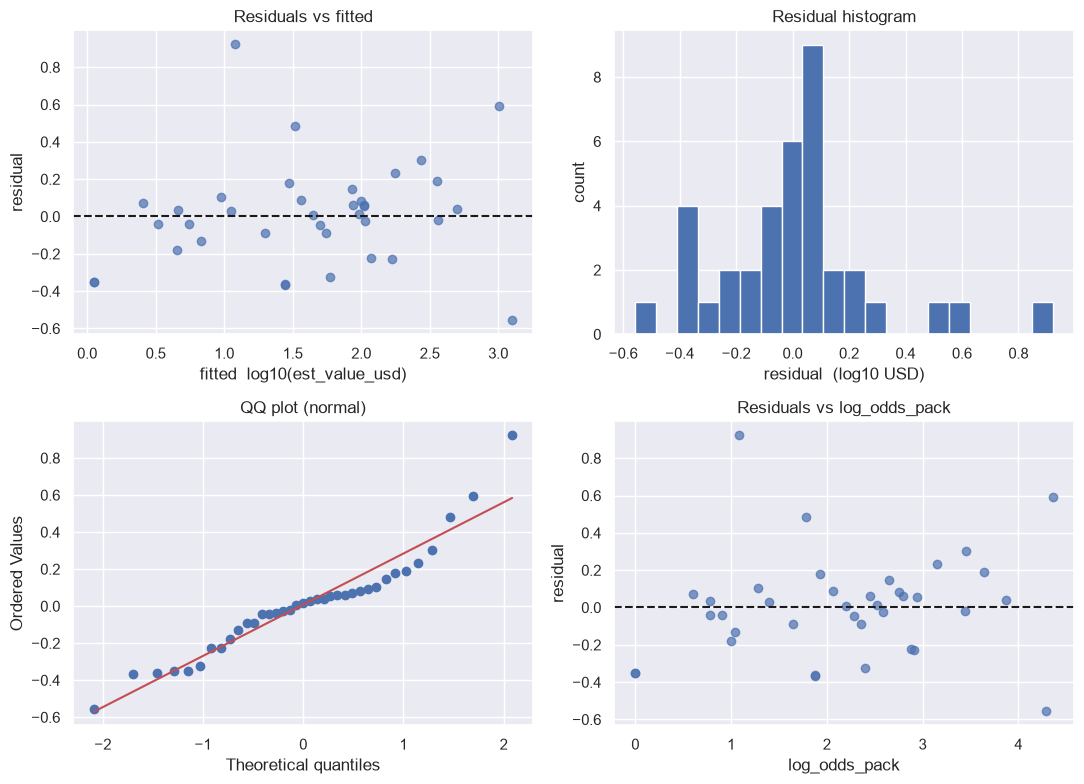

In [5]:
resid  = (y_test - y_pred).to_numpy()
fitted = y_pred

fig, ax = plt.subplots(2, 2, figsize=(11, 8))

ax[0, 0].scatter(fitted, resid, alpha=.7); ax[0, 0].axhline(0, ls="--", c="k")
ax[0, 0].set(title="Residuals vs fitted", xlabel="fitted  log10(est_value_usd)", ylabel="residual")

ax[0, 1].hist(resid, bins=20)
ax[0, 1].set(title="Residual histogram", xlabel="residual  (log10 USD)", ylabel="count")

st.probplot(resid, dist="norm", plot=ax[1, 0])
ax[1, 0].set(title="QQ plot (normal)")

ax[1, 1].scatter(X_test["log_odds_pack"], resid, alpha=.7); ax[1, 1].axhline(0, ls="--", c="k")
ax[1, 1].set(title="Residuals vs log_odds_pack", xlabel="log_odds_pack", ylabel="residual")

plt.tight_layout(); plt.show()

In [6]:
# Numeric checks behind the interpretation below.
rs = pd.Series(resid)
print(f"residual skew           = {rs.skew():.2f}")
print(f"residual excess kurtosis = {rs.kurtosis():.2f}")
print(f"Shapiro-Wilk p           = {st.shapiro(resid).pvalue:.3f}   (< 0.05 -> not normal)")
print(f"corr(|residual|, fitted) = {np.corrcoef(np.abs(resid), fitted)[0, 1]:.2f}   (near 0 -> homoscedastic)")
print("independence: not a time series -> residual autocorrelation is N/A;")
print("              sibling tiers within a product share a checklist design (see interpretation).")

residual skew           = 0.91
residual excess kurtosis = 2.50
Shapiro-Wilk p           = 0.020   (< 0.05 -> not normal)
corr(|residual|, fitted) = 0.08   (near 0 -> homoscedastic)
independence: not a time series -> residual autocorrelation is N/A;
              sibling tiers within a product share a checklist design (see interpretation).


## 4. (Optional) Add a transformed feature

Add an interaction if the diagnostics suggest mis-specification, and auto-try a few feature sets.

In [7]:
model_df["auto_x_odds"] = model_df["is_autograph"] * model_df["log_odds_pack"]

def fit_variant(name, feature_cols, target=TARGET, data=model_df, test_size=0.2, seed=7):
    d = data.dropna(subset=feature_cols + [target])
    Xtr, Xte, ytr, yte = train_test_split(d[feature_cols], d[target],
                                          test_size=test_size, random_state=seed)
    m = LinearRegression().fit(Xtr, ytr)
    p = m.predict(Xte)
    return dict(variant=name, n=len(d), k=len(feature_cols),
                r2=r2_score(yte, p),
                rmse=float(np.sqrt(mean_squared_error(yte, p))))

variants = {
    "odds only":    ["log_odds_pack"],
    "+ flags":      ["log_odds_pack", "is_numbered", "is_autograph", "is_ssp"],
    "+ tier_group": FEATURES,
    "+ auto_x_odds": FEATURES + ["auto_x_odds"],
}
pd.DataFrame(fit_variant(k, v) for k, v in variants.items()).set_index("variant").round(4)

,n,k,r2,rmse
variant,,,,
odds only,181,1,0.8654,0.3141
+ flags,181,4,0.8914,0.2821
+ tier_group,181,8,0.8960,0.2761
+ auto_x_odds,181,9,0.9573,0.1769


## 5. Interpretation

**Model.** `log10(est_value_usd) ~ log_odds_pack + is_numbered + is_autograph + is_ssp +
tg_{parallel,insert,auto,variation}` (`tg_base` = reference). 181 rows, random 80/20 split
(`random_state=7`). **train R² 0.80 / RMSE 0.32; test R² 0.896 / RMSE 0.276** (log10 USD;
RMSE 0.28 ≈ a typical miss of 10^0.28 ≈ 1.9×). The test score being *above* the train score
is a small-sample split artifact, not evidence of great generalisation — read the 0.896 as
"roughly 0.8–0.9," not a hard number.

**Coefficients** (target is log10 USD, so `10**coef` = a value multiplier):
- `log_odds_pack` ≈ 0.63 → every 10× rarer ≈ **4.3× more valuable** — the dominant driver.
- `is_numbered` ≈ 0.23 → serial-numbered cards carry a **~1.7× premium** at the same odds.
- `is_autograph` ≈ 0.17 → **~1.5× auto premium**, holding rarity fixed.
- `is_ssp` ≈ **−0.54** → *negative*: an SSP-flagged tier looks worth ~0.3× a non-SSP tier at
  the same odds. A placeholder artifact — the ladder gives plain SSP inserts a flat ~$150
  while a numbered parallel at similar odds gets ~$500, and the few real Alter Egos / Minions
  comps aren't enough to outweigh it.
- `tier_group` terms are small (≤ 0.17) except `tg_variation` ≈ −0.27 (variations are cheap
  in the ladder).

**Assumptions** (numbers from the diagnostics cell):
- *Linearity* — OK after the log transform. `log_odds_pack` alone already gives R² 0.87; hw07
  showed a straight line on *raw* odds fails (R² 0.20). Residuals-vs-`log_odds_pack` still
  slopes slightly: the plane under-predicts the rarest tiers.
- *Homoscedasticity* — OK. `corr(|residual|, fitted)` ≈ 0.08 and no funnel in
  residuals-vs-fitted. The log target did the work; a raw-USD target ($10k next to $0.50
  cards) would be badly heteroscedastic.
- *Normality* — **fails.** Shapiro–Wilk p = 0.02, residual skew ≈ 0.91, excess kurtosis ≈ 2.5
  — a fat right tail from the SSP / autograph chase tiers the linear fit can't reach.
  Consequence: prediction intervals would be too narrow on the upside.
- *Independence* — not a time series, so autocorrelation is N/A. But tiers within one product
  share a checklist design (the same refractor rainbow), so sibling tiers aren't fully
  independent and a random split can put them on both sides. `GroupShuffleSplit` on
  `product_line` would be stricter; acceptable for a baseline.

**Which model do I trust?** The `+ auto_x_odds` variant jumps to R² ≈ 0.96, but the target is
the deterministic `est_value()` ladder — a function of these same features — so gains past
~0.89 are fitting the ladder's shape, not learning market value. I trust **`+ flags` /
`+ tier_group`** (R² ≈ 0.89, RMSE ≈ 0.28): parsimonious, and the interaction's extra ~0.06 is
circular.

**Risk-aware note.** These coefficients describe the *placeholder ladder's* implied rule, not
the secondary market. **Do not feed this model's predictions into the buy/pass EV
calculation.** The non-normal, right-skewed residuals mean even the ladder-fit systematically
under-values chase tiers.

**Next steps.** Replace `est_value_usd` with real eBay sold-comp medians
(`data/raw/tier_comps.csv`) and refit — R² will drop and finally *mean* something. Then:
grouped train/test split by product; Ridge if `tg_*` + interactions get collinear; a
tree / gradient-boosting baseline for comparison; add player/subject once comps exist
(hw08: subject dominates value).